# Advanced Applications of Deep Learning

**Difficulty**: 🔴🔴🔴 Moderate-Advanced  
**Estimated Time**: ⏱️ ~3 hours

Welcome to the final lab of the deep learning course! In this notebook, we'll explore three powerful applications that go beyond standard supervised classification:

1. **Autoencoders** - Learning compressed representations and reconstruction
2. **Variational Autoencoders (VAEs)** - Probabilistic models for generation
3. **Siamese Networks** - Learning similarity and embeddings with triplet loss

These architectures demonstrate different paradigms in deep learning:
- **Autoencoders**: Unsupervised representation learning
- **VAEs**: Generative modeling with probabilistic latent spaces
- **Siamese Networks**: Metric learning for similarity tasks

## Learning Objectives

By the end of this lab, you will:
- Understand how autoencoders compress and reconstruct data
- Implement the reparameterization trick for VAEs
- Generate new images from random latent vectors
- Build Siamese networks with shared weight encoders
- Implement triplet loss for similarity learning
- Visualize learned embedding spaces
- Apply models to one-shot learning tasks

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tqdm import tqdm
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


---

# Part 1: Autoencoders

## What is an Autoencoder?

An **autoencoder** is a neural network trained to reconstruct its input. It consists of two main components:

1. **Encoder**: Compresses the input into a lower-dimensional latent representation
2. **Decoder**: Reconstructs the original input from the latent representation

```
Input (784) → Encoder → Latent Code (32) → Decoder → Reconstruction (784)
```

### Why Autoencoders?

- **Dimensionality reduction**: Like PCA but nonlinear
- **Denoising**: Learn to remove noise from data
- **Feature learning**: The latent code captures important features
- **Anomaly detection**: Reconstruction error indicates anomalies

### Architecture

We'll build a simple fully-connected autoencoder for MNIST:

- **Encoder**: 784 → 256 → 128 → 32 (latent dimension)
- **Decoder**: 32 → 128 → 256 → 784
- **Loss**: Mean Squared Error (MSE) between input and reconstruction

In [2]:
# Load MNIST dataset for autoencoder and VAE sections
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset_mnist = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset_mnist = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

train_loader_mnist = DataLoader(train_dataset_mnist, batch_size=128, shuffle=True)
test_loader_mnist = DataLoader(test_dataset_mnist, batch_size=128, shuffle=False)

print(f"MNIST Training samples: {len(train_dataset_mnist)}")
print(f"MNIST Test samples: {len(test_dataset_mnist)}")

MNIST Training samples: 60000
MNIST Test samples: 10000


## Exercise 1: Implement the Autoencoder 🔴🔴 (15 min)

**Task**: Implement the `Autoencoder` class with encoder and decoder networks.

**Important**: 🔵🔵🔵
- The encoder should compress 784 → 256 → 128 → 32
- The decoder should expand 32 → 128 → 256 → 784
- Use ReLU activation in hidden layers
- Use Sigmoid activation for the final output (images are [0, 1])

**Hints**:
- Input images need to be flattened: `x.view(batch_size, -1)`
- Output needs to be reshaped back: `x.view(batch_size, 1, 28, 28)`

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        
        # TODO: Implement encoder
        # 784 -> 256 -> 128 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        
        # TODO: Implement decoder
        # latent_dim -> 128 -> 256 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()  # Output between [0, 1]
        )
    
    def forward(self, x):
        # TODO: Implement forward pass
        # 1. Flatten input
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        
        # 2. Encode
        latent = self.encoder(x)
        
        # 3. Decode
        reconstruction = self.decoder(latent)
        
        # 4. Reshape back to image
        reconstruction = reconstruction.view(batch_size, 1, 28, 28)
        
        return reconstruction, latent

# Test the model
model_ae = Autoencoder(latent_dim=32).to(device)
print(model_ae)
print(f"\nTotal parameters: {sum(p.numel() for p in model_ae.parameters()):,}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 476,720


## Training the Autoencoder

We'll train the autoencoder to minimize the reconstruction loss (MSE between input and output).

In [4]:
def train_autoencoder(model, train_loader, num_epochs=10, learning_rate=1e-3):
    """
    Train the autoencoder.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            
            # Forward pass
            reconstructions, _ = model(images)
            loss = criterion(reconstructions, images)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")
    
    return train_losses

# Train the model
print("Training Autoencoder...")
ae_losses = train_autoencoder(model_ae, train_loader_mnist, num_epochs=10)

Training Autoencoder...


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 469/469 [00:02<00:00, 168.90it/s]


Epoch [1/10], Loss: 0.051101


Epoch 2/10: 100%|██████████| 469/469 [00:02<00:00, 181.16it/s]


...

Epoch [8/10], Loss: 0.010181


Epoch 9/10: 100%|██████████| 469/469 [00:02<00:00, 191.28it/s]


Epoch [9/10], Loss: 0.009496


Epoch 10/10: 100%|██████████| 469/469 [00:02<00:00, 190.82it/s]

Epoch [10/10], Loss: 0.008924


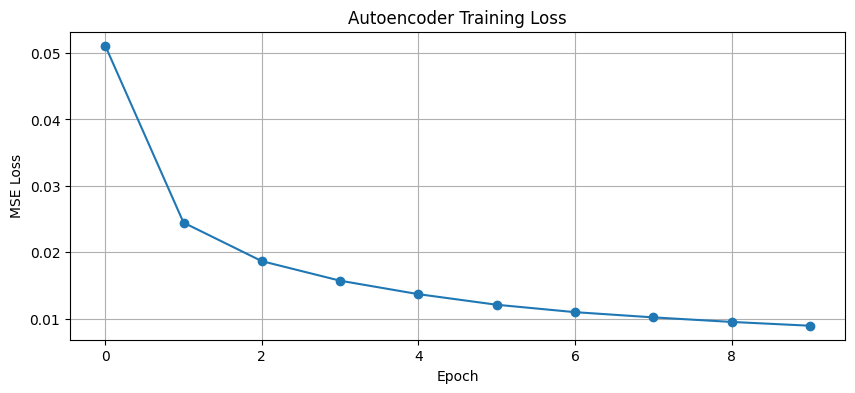

In [5]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(ae_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.grid(True)
plt.show()

## Visualizing Reconstructions

Let's see how well the autoencoder reconstructs MNIST digits.

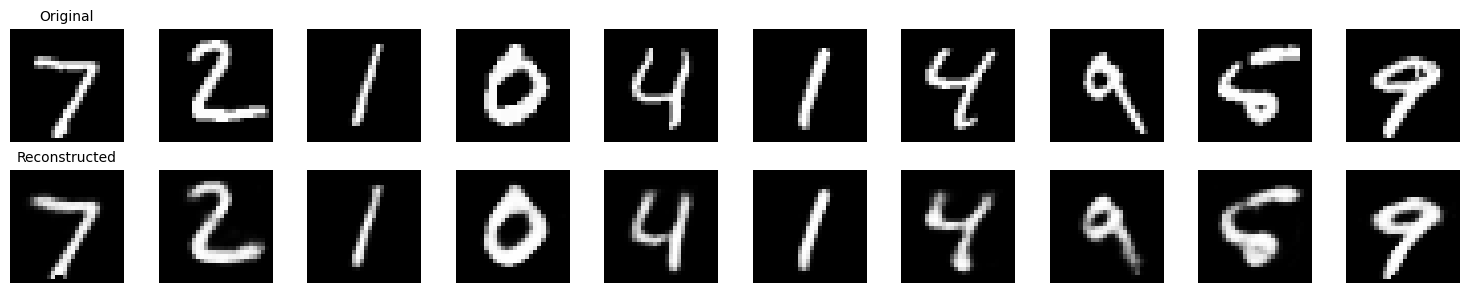

In [6]:
def visualize_reconstructions(model, test_loader, num_images=10):
    """
    Visualize original images and their reconstructions.
    """
    model.eval()
    
    # Get a batch of test images
    images, _ = next(iter(test_loader))
    images = images[:num_images].to(device)
    
    with torch.no_grad():
        reconstructions, _ = model(images)
    
    # Move to CPU for plotting
    images = images.cpu()
    reconstructions = reconstructions.cpu()
    
    # Plot
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 1.5, 3))
    
    for i in range(num_images):
        # Original
        axes[0, i].imshow(images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)
        
        # Reconstruction
        axes[1, i].imshow(reconstructions[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)
    
    plt.tight_layout()
    plt.show()

visualize_reconstructions(model_ae, test_loader_mnist, num_images=10)

---

# Part 2: Variational Autoencoders (VAEs)

## What is a VAE?

A **Variational Autoencoder (VAE)** is a generative model that learns a probabilistic mapping between data and a latent space.

### Key Differences from Autoencoders:

| Autoencoder | VAE |
|-------------|-----|
| Deterministic encoding | Probabilistic encoding |
| Encoder outputs latent code `z` | Encoder outputs mean `μ` and variance `σ²` |
| Can only reconstruct | Can **generate** new samples |
| Latent space may have gaps | Continuous, structured latent space |

### VAE Architecture

```
Input → Encoder → (μ, log σ²) → Sample z ~ N(μ, σ²) → Decoder → Reconstruction
                                      ↑
                              Reparameterization Trick
```

### The Reparameterization Trick

To enable backpropagation through sampling, we use:

```
z = μ + σ * ε,  where ε ~ N(0, 1)
```

This allows gradients to flow through `μ` and `σ`.

### VAE Loss Function

The VAE loss has two components:

1. **Reconstruction Loss**: How well can we reconstruct the input?
   - Binary Cross-Entropy or MSE

2. **KL Divergence**: How close is the learned distribution to N(0, 1)?
   - `KL(N(μ, σ²) || N(0, 1)) = -0.5 * Σ(1 + log(σ²) - μ² - σ²)`

```python
Total Loss = Reconstruction Loss + β * KL Divergence
```

The `β` parameter controls the trade-off. Higher β → more regularized latent space.

## Exercise 2: Implement the VAE 🔴🔴🔴 (20 min)

**Task**: Implement the `VAE` class with:
1. Encoder that outputs `mu` and `log_var`
2. Reparameterization trick
3. Decoder

**Important**: 🔵🔵🔵
- The encoder outputs **two** tensors: `mu` and `log_var` (not variance directly!)
- Use the reparameterization trick: `z = mu + std * epsilon`
- `std = exp(0.5 * log_var)`

**Hints**:
- Why `log_var`? Numerical stability and ensuring positivity
- Sample `epsilon ~ N(0, 1)` using `torch.randn_like(std)`

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()
        
        # TODO: Implement encoder (outputs mu and log_var)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        # Separate layers for mu and log_var
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_log_var = nn.Linear(128, latent_dim)
        
        # TODO: Implement decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        """
        Encode input to latent parameters mu and log_var.
        """
        # TODO: Implement encoding
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick: z = mu + std * epsilon
        """
        # TODO: Implement reparameterization trick
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z
    
    def decode(self, z):
        """
        Decode latent vector to reconstruction.
        """
        # TODO: Implement decoding
        x = self.decoder(z)
        x = x.view(x.size(0), 1, 28, 28)
        return x
    
    def forward(self, x):
        # TODO: Implement full forward pass
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decode(z)
        return reconstruction, mu, log_var

# Test the model
model_vae = VAE(latent_dim=32).to(device)
print(model_vae)
print(f"\nTotal parameters: {sum(p.numel() for p in model_vae.parameters()):,}")

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=32, bias=True)
  (fc_log_var): Linear(in_features=128, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 480,848


## Exercise 3: Implement VAE Loss Function 🔴🔴 (15 min)

**Task**: Implement the VAE loss function combining reconstruction loss and KL divergence.

**Important**: 🔵🔵🔵
- Use Binary Cross-Entropy for reconstruction loss
- KL divergence formula: `-0.5 * sum(1 + log_var - mu² - exp(log_var))`
- Return both total loss and individual components for monitoring

**Hints**:
- `F.binary_cross_entropy(reconstruction, target, reduction='sum')`
- Average over batch: divide by batch size

In [8]:
def vae_loss(reconstruction, x, mu, log_var, beta=1.0):
    """
    VAE loss = Reconstruction loss + beta * KL divergence
    
    Args:
        reconstruction: Reconstructed images
        x: Original images
        mu: Mean of latent distribution
        log_var: Log variance of latent distribution
        beta: Weight for KL divergence term
    
    Returns:
        total_loss, reconstruction_loss, kl_divergence
    """
    # TODO: Implement reconstruction loss (Binary Cross-Entropy)
    batch_size = x.size(0)
    recon_loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    recon_loss = recon_loss / batch_size
    
    # TODO: Implement KL divergence
    # KL(N(mu, sigma^2) || N(0, 1)) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    kl_div = kl_div / batch_size
    
    # TODO: Combine losses
    total_loss = recon_loss + beta * kl_div
    
    return total_loss, recon_loss, kl_div

## Training the VAE

In [9]:
def train_vae(model, train_loader, num_epochs=10, learning_rate=1e-3, beta=1.0):
    """
    Train the VAE.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    model.train()
    train_losses = []
    recon_losses = []
    kl_losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        
        for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            
            # Forward pass
            reconstructions, mu, log_var = model(images)
            loss, recon_loss, kl_div = vae_loss(reconstructions, images, mu, log_var, beta)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_div.item()
        
        avg_loss = epoch_loss / len(train_loader)
        avg_recon = epoch_recon / len(train_loader)
        avg_kl = epoch_kl / len(train_loader)
        
        train_losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}")
    
    return train_losses, recon_losses, kl_losses

# Train the model
print("Training VAE...")
vae_losses, vae_recon, vae_kl = train_vae(model_vae, train_loader_mnist, num_epochs=10, beta=1.0)

Training VAE...


Epoch 1/10: 100%|██████████| 469/469 [00:02<00:00, 167.68it/s]


Epoch [1/10], Loss: 193.3928, Recon: 187.1169, KL: 6.2759


Epoch 2/10: 100%|██████████| 469/469 [00:02<00:00, 162.22it/s]


Epoch [2/10], Loss: 144.2938, Recon: 130.2749, KL: 14.0189


...

Epoch [8/10], Loss: 110.1436, Recon: 91.7925, KL: 18.3511


Epoch 9/10: 100%|██████████| 469/469 [00:03<00:00, 130.72it/s]


Epoch [9/10], Loss: 109.1485, Recon: 90.5731, KL: 18.5754


Epoch 10/10: 100%|██████████| 469/469 [00:02<00:00, 160.37it/s]

Epoch [10/10], Loss: 108.2790, Recon: 89.5293, KL: 18.7497


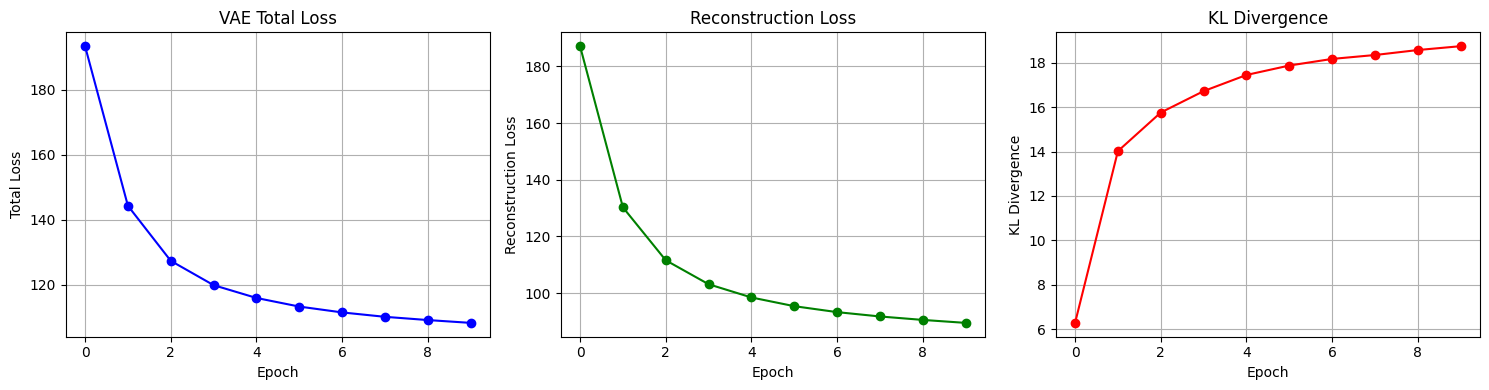

In [10]:
# Plot training losses
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae_losses, marker='o', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('VAE Total Loss')
axes[0].grid(True)

axes[1].plot(vae_recon, marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss')
axes[1].grid(True)

axes[2].plot(vae_kl, marker='o', color='red')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Generating New Images

The key advantage of VAEs: we can **generate** new images by sampling from the latent space!

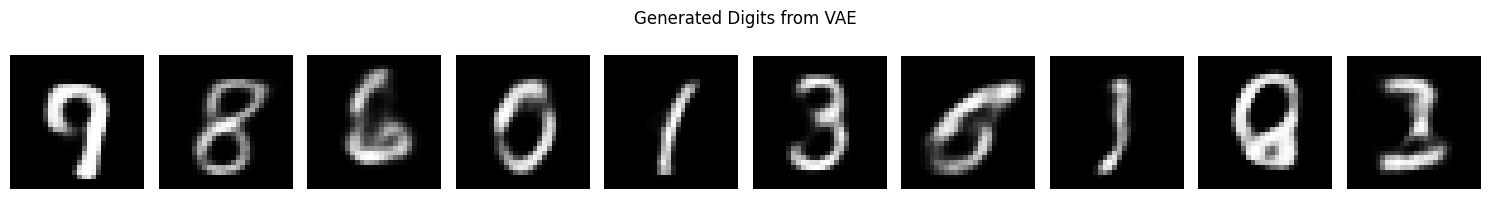

In [11]:
def generate_images(model, num_images=10, latent_dim=32):
    """
    Generate new images by sampling from the latent space.
    """
    model.eval()
    
    with torch.no_grad():
        # Sample from standard normal distribution
        z = torch.randn(num_images, latent_dim).to(device)
        
        # Decode to images
        generated = model.decode(z)
    
    # Plot
    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 1.5, 2))
    
    for i in range(num_images):
        axes[i].imshow(generated[i].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')
    
    plt.suptitle('Generated Digits from VAE', fontsize=12)
    plt.tight_layout()
    plt.show()

generate_images(model_vae, num_images=10, latent_dim=32)

## Latent Space Interpolation

We can interpolate between two points in latent space to see smooth transitions.

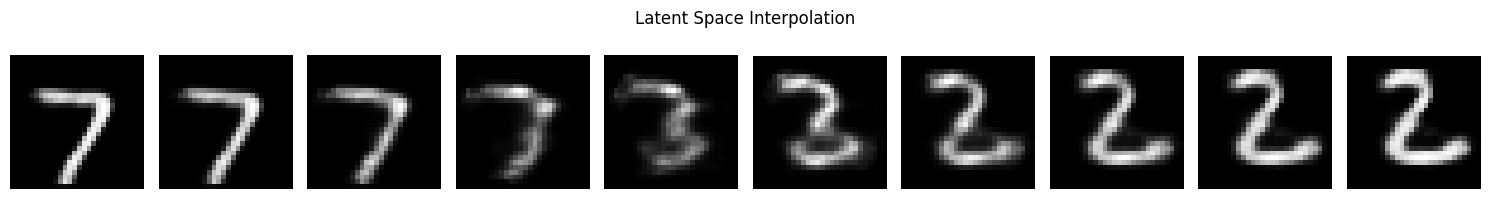

In [12]:
def interpolate_latent_space(model, test_loader, num_steps=10):
    """
    Interpolate between two random images in latent space.
    """
    model.eval()
    
    # Get two random images
    images, _ = next(iter(test_loader))
    img1, img2 = images[0:1].to(device), images[1:2].to(device)
    
    with torch.no_grad():
        # Encode both images
        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)
        
        # Interpolate in latent space
        interpolations = []
        for alpha in np.linspace(0, 1, num_steps):
            z = (1 - alpha) * mu1 + alpha * mu2
            decoded = model.decode(z)
            interpolations.append(decoded.cpu().squeeze())
    
    # Plot
    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 1.5, 2))
    
    for i in range(num_steps):
        axes[i].imshow(interpolations[i], cmap='gray')
        axes[i].axis('off')
    
    plt.suptitle('Latent Space Interpolation', fontsize=12)
    plt.tight_layout()
    plt.show()

interpolate_latent_space(model_vae, test_loader_mnist, num_steps=10)

---

# Part 3: Siamese Networks with Triplet Loss

## What is a Siamese Network?

A **Siamese Network** learns to measure similarity between inputs. It consists of:

- **Twin networks** with **shared weights** (same encoder applied to different inputs)
- **Distance metric** to compare embeddings (Euclidean, Cosine)
- **Similarity loss** to train the network (Contrastive, Triplet)

### Applications

- **Face verification**: "Are these two faces the same person?"
- **One-shot learning**: Learn from very few examples
- **Image similarity search**: Find similar images
- **Signature verification**: Detect forgeries

## Triplet Loss

Triplet loss works with triplets of examples:

1. **Anchor (A)**: Reference image
2. **Positive (P)**: Same class as anchor
3. **Negative (N)**: Different class from anchor

### Goal

Make the distance between Anchor and Positive **smaller** than the distance between Anchor and Negative:

```
d(A, P) + margin < d(A, N)
```

### Triplet Loss Formula

```
L = max(d(A, P) - d(A, N) + margin, 0)
```

Where:
- `d(x, y)` is the distance between embeddings (we'll use cosine distance)
- `margin` is a hyperparameter (typically 0.2-1.0)

### Cosine Distance

Cosine distance measures the angle between vectors:

```
cosine_distance = 1 - cosine_similarity
cosine_similarity = (x · y) / (||x|| * ||y||)
```

- Cosine distance = 0 → identical direction
- Cosine distance = 2 → opposite direction

## Omniglot Dataset

We'll use the **Omniglot** dataset:
- 50 alphabets, 1623 characters total
- 20 examples per character (different people writing it)
- Perfect for few-shot learning!

We'll use a subset for computational efficiency.

Omniglot Training samples: 1600
Omniglot Test samples: 400


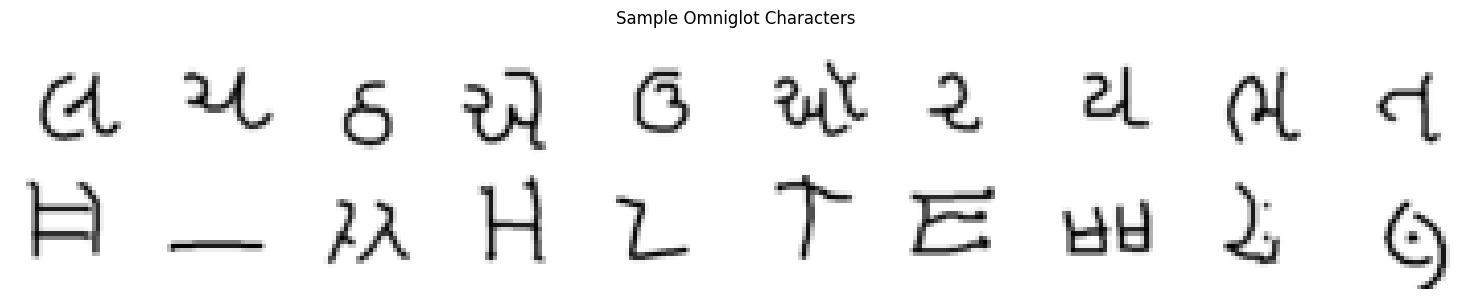

In [13]:
# Load Omniglot dataset
transform_omniglot = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

# Download full dataset
omniglot_full = torchvision.datasets.Omniglot(
    root='./data',
    background=True,
    download=True,
    transform=transform_omniglot
)

# Create a subset: select first 100 characters (20 examples each = 2000 images)
# This makes training faster while still being challenging
num_characters = 100
samples_per_character = 20
subset_indices = list(range(num_characters * samples_per_character))

train_dataset_omniglot = Subset(omniglot_full, subset_indices[:1600])  # 80 characters for training
test_dataset_omniglot = Subset(omniglot_full, subset_indices[1600:])  # 20 characters for testing

print(f"Omniglot Training samples: {len(train_dataset_omniglot)}")
print(f"Omniglot Test samples: {len(test_dataset_omniglot)}")

# Visualize some examples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    img, label = omniglot_full[i * 100]  # Sample different characters
    axes[i // 10, i % 10].imshow(img.squeeze(), cmap='gray')
    axes[i // 10, i % 10].axis('off')
plt.suptitle('Sample Omniglot Characters', fontsize=12)
plt.tight_layout()
plt.show()

## Triplet Dataset

We need to create triplets (Anchor, Positive, Negative) for training.

In [14]:
class TripletDataset(Dataset):
    """
    Dataset that generates triplets (anchor, positive, negative) for triplet loss.
    """
    def __init__(self, dataset, num_triplets=10000):
        self.dataset = dataset
        self.num_triplets = num_triplets
        
        # Organize images by label
        self.label_to_indices = {}
        for idx in range(len(dataset)):
            _, label = dataset[idx]
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)
        
        self.labels = list(self.label_to_indices.keys())
    
    def __len__(self):
        return self.num_triplets
    
    def __getitem__(self, idx):
        # Select a random label for anchor and positive
        anchor_label = random.choice(self.labels)
        
        # Select anchor and positive from same class
        anchor_idx, positive_idx = random.sample(self.label_to_indices[anchor_label], 2)
        
        # Select negative from different class
        negative_label = random.choice([l for l in self.labels if l != anchor_label])
        negative_idx = random.choice(self.label_to_indices[negative_label])
        
        # Get images
        anchor_img, _ = self.dataset[anchor_idx]
        positive_img, _ = self.dataset[positive_idx]
        negative_img, _ = self.dataset[negative_idx]
        
        return anchor_img, positive_img, negative_img

# Create triplet datasets
train_triplet_dataset = TripletDataset(train_dataset_omniglot, num_triplets=5000)
test_triplet_dataset = TripletDataset(test_dataset_omniglot, num_triplets=1000)

train_loader_triplet = DataLoader(train_triplet_dataset, batch_size=32, shuffle=True)
test_loader_triplet = DataLoader(test_triplet_dataset, batch_size=32, shuffle=False)

print(f"Training triplets: {len(train_triplet_dataset)}")
print(f"Test triplets: {len(test_triplet_dataset)}")

Training triplets: 5000
Test triplets: 1000


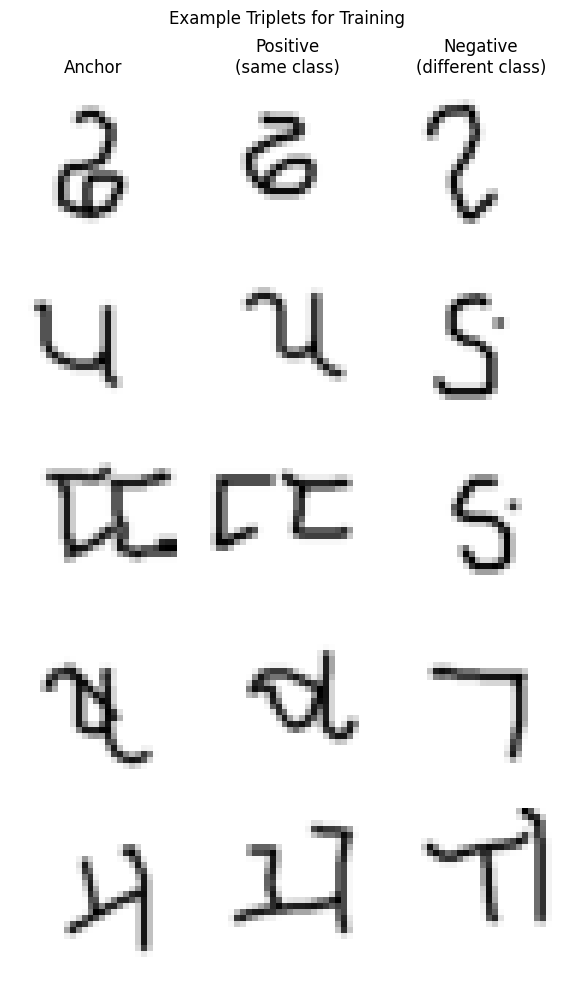

In [15]:
# Visualize some triplets
def visualize_triplets(dataset, num_triplets=5):
    fig, axes = plt.subplots(num_triplets, 3, figsize=(6, num_triplets * 2))
    
    for i in range(num_triplets):
        anchor, positive, negative = dataset[i]
        
        axes[i, 0].imshow(anchor.squeeze(), cmap='gray')
        axes[i, 0].set_title('Anchor' if i == 0 else '')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(positive.squeeze(), cmap='gray')
        axes[i, 1].set_title('Positive\n(same class)' if i == 0 else '')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(negative.squeeze(), cmap='gray')
        axes[i, 2].set_title('Negative\n(different class)' if i == 0 else '')
        axes[i, 2].axis('off')
    
    plt.suptitle('Example Triplets for Training', fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_triplets(train_triplet_dataset, num_triplets=5)

## Exercise 4: Implement Siamese Network 🔴🔴🔴 (25 min)

**Task**: Implement:
1. A simple CNN feature extractor
2. The `SiameseNetwork` class that uses shared weights
3. The triplet loss function with cosine distance

**Important**: 🔵🔵🔵
- The feature extractor should be a **single network** used for all three inputs
- Use `F.cosine_similarity()` for computing similarity
- Cosine distance = `1 - cosine_similarity`
- Normalize embeddings using `F.normalize()` before computing distance

**Hints**:
- CNN structure: Conv(1→32) → Conv(32→64) → Flatten → FC(→128)
- The forward pass takes 3 inputs and returns 3 embeddings

In [16]:
class FeatureExtractor(nn.Module):
    """
    Simple CNN for extracting features from images.
    """
    def __init__(self, embedding_dim=128):
        super(FeatureExtractor, self).__init__()
        
        # TODO: Implement CNN feature extractor
        self.conv = nn.Sequential(
            # Conv block 1: 1 -> 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28x28 -> 14x14
            
            # Conv block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14x14 -> 7x7
        )
        
        # TODO: Implement fully connected layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )
    
    def forward(self, x):
        # TODO: Implement forward pass
        x = self.conv(x)
        x = self.fc(x)
        # Normalize embeddings to unit length (important for cosine distance)
        x = F.normalize(x, p=2, dim=1)
        return x


class SiameseNetwork(nn.Module):
    """
    Siamese Network with shared feature extractor.
    """
    def __init__(self, embedding_dim=128):
        super(SiameseNetwork, self).__init__()
        
        # TODO: Create the shared feature extractor
        self.feature_extractor = FeatureExtractor(embedding_dim)
    
    def forward(self, anchor, positive, negative):
        """
        Forward pass with triplet inputs.
        
        Args:
            anchor: Anchor images
            positive: Positive images (same class as anchor)
            negative: Negative images (different class)
        
        Returns:
            anchor_embedding, positive_embedding, negative_embedding
        """
        # TODO: Extract features using the SAME network (shared weights)
        anchor_emb = self.feature_extractor(anchor)
        positive_emb = self.feature_extractor(positive)
        negative_emb = self.feature_extractor(negative)
        
        return anchor_emb, positive_emb, negative_emb
    
    def get_embedding(self, x):
        """
        Get embedding for a single image (used for inference).
        """
        return self.feature_extractor(x)


# Test the model
model_siamese = SiameseNetwork(embedding_dim=128).to(device)
print(model_siamese)
print(f"\nTotal parameters: {sum(p.numel() for p in model_siamese.parameters()):,}")

SiameseNetwork(
  (feature_extractor): FeatureExtractor(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=3136, out_features=256, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
    )
  )
)

Total parameters: 854,784


## Exercise 5: Implement Triplet Loss 🔴🔴 (15 min)

**Task**: Implement the triplet loss function using cosine distance.

**Important**: 🔵🔵🔵
- Cosine distance = `1 - cosine_similarity`
- Use `F.cosine_similarity(x, y, dim=1)` to compute similarity
- Loss = `max(d(A, P) - d(A, N) + margin, 0)`

**Hints**:
- `F.cosine_similarity` returns values in [-1, 1]
- Distance in [0, 2] where 0 = identical, 2 = opposite
- Use `torch.clamp()` or `F.relu()` for the max operation

In [17]:
def triplet_loss(anchor, positive, negative, margin=0.5):
    """
    Triplet loss with cosine distance.
    
    Args:
        anchor: Anchor embeddings (batch_size, embedding_dim)
        positive: Positive embeddings (batch_size, embedding_dim)
        negative: Negative embeddings (batch_size, embedding_dim)
        margin: Margin for triplet loss
    
    Returns:
        loss: Triplet loss value
    """
    # TODO: Compute cosine similarity
    # cosine_similarity returns values in [-1, 1]
    positive_similarity = F.cosine_similarity(anchor, positive, dim=1)
    negative_similarity = F.cosine_similarity(anchor, negative, dim=1)
    
    # TODO: Convert to cosine distance
    # distance = 1 - similarity, so distance in [0, 2]
    positive_distance = 1 - positive_similarity
    negative_distance = 1 - negative_similarity
    
    # TODO: Compute triplet loss
    # L = max(d(A, P) - d(A, N) + margin, 0)
    losses = F.relu(positive_distance - negative_distance + margin)
    
    return losses.mean()

# Test the loss function
test_anchor = torch.randn(4, 128).to(device)
test_positive = test_anchor + 0.1 * torch.randn(4, 128).to(device)  # Similar to anchor
test_negative = torch.randn(4, 128).to(device)  # Random (different)

# Normalize
test_anchor = F.normalize(test_anchor, p=2, dim=1)
test_positive = F.normalize(test_positive, p=2, dim=1)
test_negative = F.normalize(test_negative, p=2, dim=1)

test_loss = triplet_loss(test_anchor, test_positive, test_negative)
print(f"Test triplet loss for similar embeddings: {test_loss.item():.4f}")

# Test the loss function
test_anchor = torch.randn(4, 128).to(device)
test_positive = torch.randn(4, 128).to(device)  # Not so similar to anchor
test_negative = torch.randn(4, 128).to(device)  # Random (different)

# Normalize
test_anchor = F.normalize(test_anchor, p=2, dim=1)
test_positive = F.normalize(test_positive, p=2, dim=1)
test_negative = F.normalize(test_negative, p=2, dim=1)

test_loss = triplet_loss(test_anchor, test_positive, test_negative)
print(f"Test triplet loss for dissimilar embeddings: {test_loss.item():.4f}")

Test triplet loss for similar embeddings: 0.0000
Test triplet loss for dissimilar embeddings: 0.5119


## Training the Siamese Network

In [18]:
def train_siamese(model, train_loader, num_epochs=20, learning_rate=1e-3, margin=0.5):
    """
    Train the Siamese Network with triplet loss.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for anchor, positive, negative in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)
            
            # Forward pass
            anchor_emb, positive_emb, negative_emb = model(anchor, positive, negative)
            loss = triplet_loss(anchor_emb, positive_emb, negative_emb, margin)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    return train_losses

# Train the model
print("Training Siamese Network...")
siamese_losses = train_siamese(model_siamese, train_loader_triplet, num_epochs=20, margin=0.5)

Training Siamese Network...


Epoch 1/20: 100%|██████████| 157/157 [00:02<00:00, 53.57it/s]


Epoch [1/20], Loss: 0.2142


Epoch 2/20: 100%|██████████| 157/157 [00:02<00:00, 56.54it/s]


Epoch [2/20], Loss: 0.1039


...

Epoch [18/20], Loss: 0.0126


Epoch 19/20: 100%|██████████| 157/157 [00:03<00:00, 51.98it/s]


Epoch [19/20], Loss: 0.0145


Epoch 20/20: 100%|██████████| 157/157 [00:02<00:00, 57.31it/s]

Epoch [20/20], Loss: 0.0120


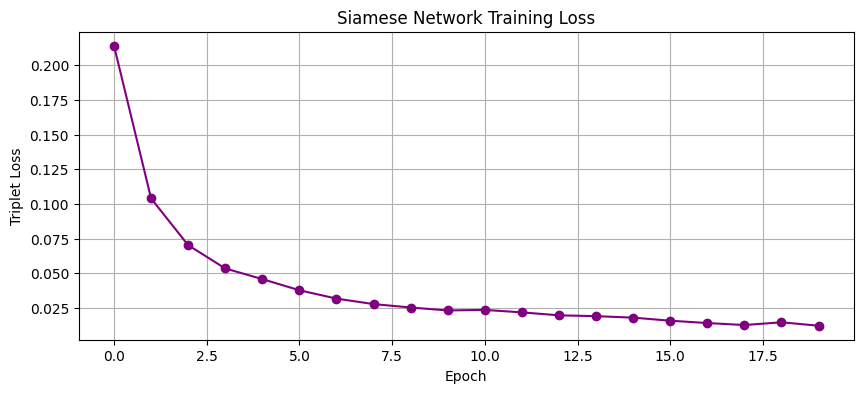

In [19]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(siamese_losses, marker='o', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.title('Siamese Network Training Loss')
plt.grid(True)
plt.show()

## Visualizing the Embedding Space

Let's visualize how well the network separates different classes in the embedding space using t-SNE.

Applying t-SNE...


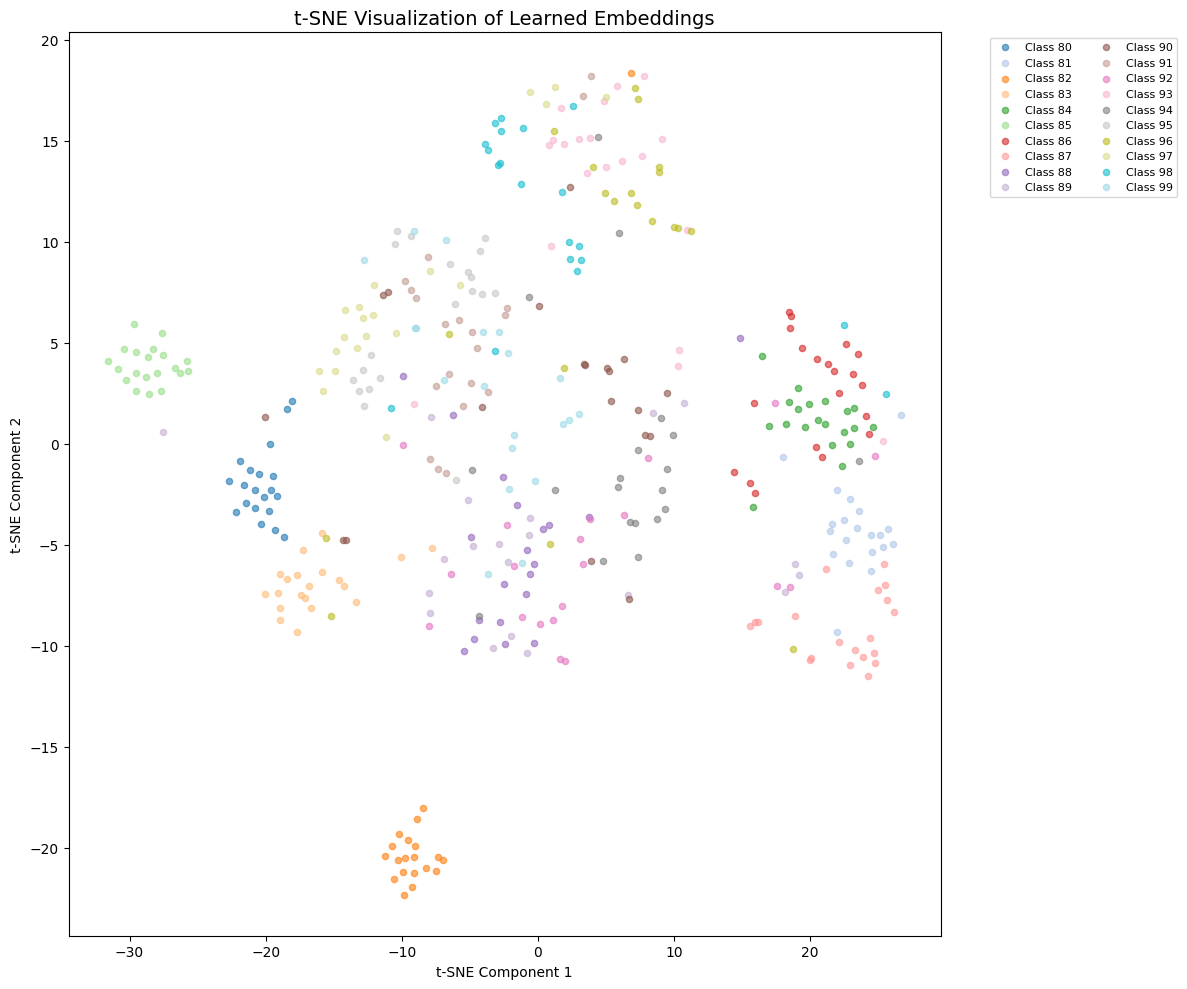

In [20]:
def visualize_embeddings(model, dataset, num_samples=500):
    """
    Visualize embeddings using t-SNE.
    """
    model.eval()
    
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for i in range(min(num_samples, len(dataset))):
            img, label = dataset[i]
            img = img.unsqueeze(0).to(device)
            
            emb = model.get_embedding(img)
            embeddings.append(emb.cpu().numpy())
            labels.append(label)
    
    embeddings = np.vstack(embeddings)
    labels = np.array(labels)
    
    # Apply t-SNE
    print("Applying t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 10))
    
    # Get unique labels and assign colors
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        mask = labels == label
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[color],
            label=f'Class {label}',
            alpha=0.6,
            s=20
        )
    
    plt.title('t-SNE Visualization of Learned Embeddings', fontsize=14)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

# Visualize embeddings from test set
visualize_embeddings(model_siamese, test_dataset_omniglot, num_samples=400)

## One-Shot Learning: Face Verification Style

Let's test the model's ability to verify if two images belong to the same class.

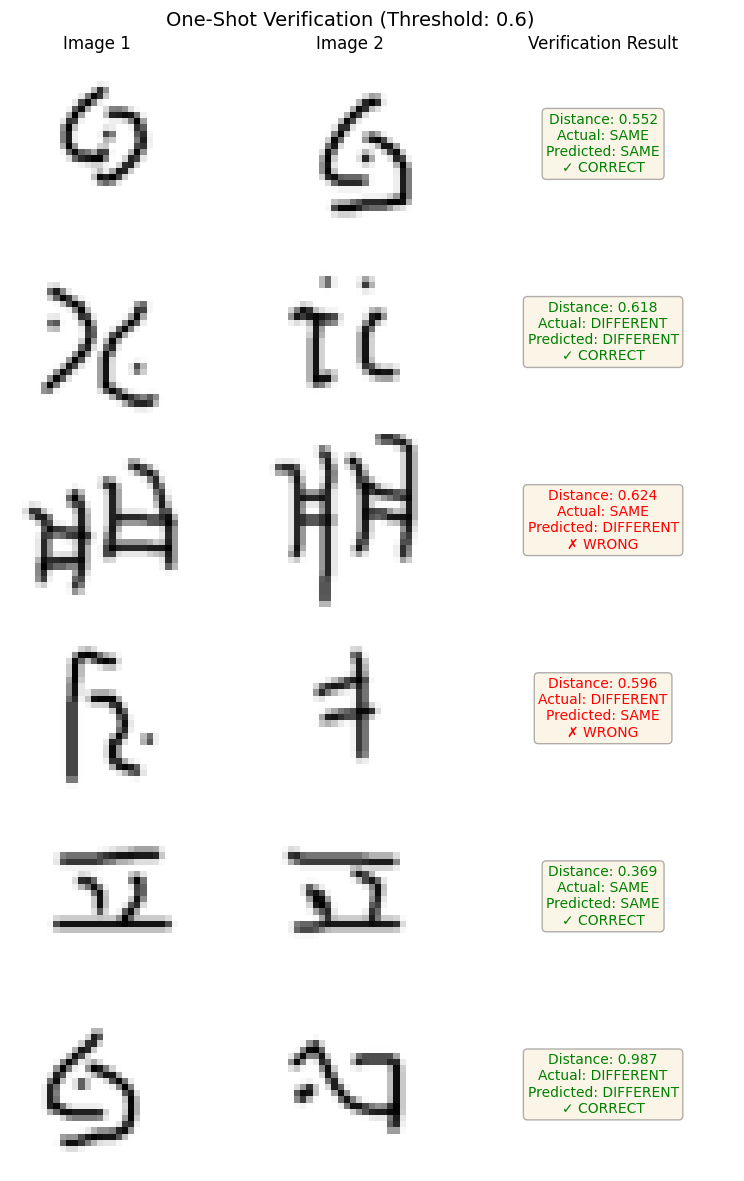

In [21]:
def verify_pairs(model, dataset, num_pairs=5, threshold=0.6):
    """
    Verify if pairs of images are from the same class.
    
    Args:
        threshold: Cosine distance threshold (lower = more similar)
    """
    model.eval()
    
    fig, axes = plt.subplots(num_pairs, 3, figsize=(8, num_pairs * 2))
    
    # Organize by labels
    label_to_indices = {}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        if label not in label_to_indices:
            label_to_indices[label] = []
        label_to_indices[label].append(idx)
    
    labels_list = list(label_to_indices.keys())
    
    for i in range(num_pairs):
        # Half should be same class, half different
        is_same_class = (i % 2 == 0)
        
        if is_same_class:
            # Pick two images from same class
            label = random.choice(labels_list)
            idx1, idx2 = random.sample(label_to_indices[label], 2)
        else:
            # Pick two images from different classes
            label1, label2 = random.sample(labels_list, 2)
            idx1 = random.choice(label_to_indices[label1])
            idx2 = random.choice(label_to_indices[label2])
        
        img1, _ = dataset[idx1]
        img2, _ = dataset[idx2]
        
        # Compute similarity
        with torch.no_grad():
            emb1 = model.get_embedding(img1.unsqueeze(0).to(device))
            emb2 = model.get_embedding(img2.unsqueeze(0).to(device))
            
            similarity = F.cosine_similarity(emb1, emb2).item()
            distance = 1 - similarity
        
        # Predict
        predicted_same = distance < threshold
        correct = (predicted_same == is_same_class)
        
        # Plot
        axes[i, 0].imshow(img1.squeeze(), cmap='gray')
        axes[i, 0].axis('off')
        if i == 0:
            axes[i, 0].set_title('Image 1')
        
        axes[i, 1].imshow(img2.squeeze(), cmap='gray')
        axes[i, 1].axis('off')
        if i == 0:
            axes[i, 1].set_title('Image 2')
        
        # Result
        axes[i, 2].axis('off')
        result_text = f"Distance: {distance:.3f}\n"
        result_text += f"Actual: {'SAME' if is_same_class else 'DIFFERENT'}\n"
        result_text += f"Predicted: {'SAME' if predicted_same else 'DIFFERENT'}\n"
        result_text += f"{'✓ CORRECT' if correct else '✗ WRONG'}"
        
        color = 'green' if correct else 'red'
        axes[i, 2].text(0.5, 0.5, result_text, 
                       ha='center', va='center',
                       fontsize=10, color=color,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        if i == 0:
            axes[i, 2].set_title('Verification Result')
    
    plt.suptitle(f'One-Shot Verification (Threshold: {threshold})', fontsize=14)
    plt.tight_layout()
    plt.show()

verify_pairs(model_siamese, test_dataset_omniglot, num_pairs=6, threshold=0.6)

## Summary and Comparison

### What We Learned

| Model | Task | Key Innovation | Use Case |
|-------|------|----------------|----------|
| **Autoencoder** | Reconstruction | Compression + Reconstruction | Denoising, Dimensionality Reduction |
| **VAE** | Generation | Probabilistic Latent Space | Generate new images, Interpolation |
| **Siamese Network** | Similarity Learning | Shared Weights + Metric Learning | Face Verification, One-Shot Learning |

### Key Takeaways

1. **Autoencoders** learn to compress data while preserving important information
   - Useful for unsupervised feature learning
   - Can't generate new samples (deterministic)

2. **VAEs** add probabilistic modeling to autoencoders
   - Can generate new samples from learned distribution
   - Reparameterization trick enables backpropagation
   - Smooth, continuous latent space

3. **Siamese Networks** learn similarity metrics
   - Shared weights ensure consistent feature extraction
   - Triplet loss encourages class separation
   - Powerful for few-shot learning scenarios

### Different Loss Functions

- **Autoencoder**: MSE (pixel-wise reconstruction)
- **VAE**: Reconstruction + KL Divergence (regularization)
- **Siamese**: Triplet Loss (metric learning)

Each approach tackles a different problem and demonstrates the versatility of deep learning beyond standard classification!

---

## Exercises for Further Exploration (Optional)

If you have extra time, try these extensions:

### 1. Convolutional Autoencoder/VAE 🔴🔴🔴
- Replace fully-connected layers with convolutional layers
- Use transposed convolutions for the decoder
- Compare reconstruction quality

### 2. β-VAE 🔴🔴
- Experiment with different β values in VAE loss
- See how it affects reconstruction vs. generation quality
- Try β = 0.5, 1.0, 2.0, 4.0

### 3. Hard Triplet Mining 🔴🔴🔴🔴
- Implement semi-hard or hard negative mining
- Only use triplets where `d(A, P) < d(A, N)` (hard negatives)
- Should improve training efficiency

### 4. K-Shot Learning 🔴🔴🔴
- Test Siamese network on k-shot learning (k > 1)
- Given k examples of a new class, classify new instances
- Measure accuracy vs. k

### 5. Conditional VAE 🔴🔴🔴🔴
- Condition VAE on class labels
- Control what digit to generate
- Requires modifying encoder and decoder

---

## Congratulations!

You've completed the final lab of the deep learning course! You now understand:

- ✅ How autoencoders compress and reconstruct data
- ✅ How VAEs generate new samples using probabilistic latent spaces
- ✅ How Siamese networks learn similarity metrics
- ✅ Different paradigms in deep learning beyond supervised classification

These techniques are fundamental to many modern applications:
- Image generation (GANs build on VAE ideas)
- Face recognition (Siamese networks)
- Anomaly detection (Autoencoders)
- Few-shot learning (Metric learning)

Great work! 🎉